## Nuevo intento - 2024 10 20 - 04:01

Fitting 10 folds for each of 605 candidates, totalling 6050 fits
Mejores hiperparámetros: {'learning_rate': 0.15000000000000002, 'n_estimators': 200, 'reg_lambda': 4.0}
Log Loss (CV): 0.131844
Matriz de confusión (CV):
[[48148   499]
 [ 2011  2323]]
Accuracy (CV): 0.952625
AUC (CV): 0.948433


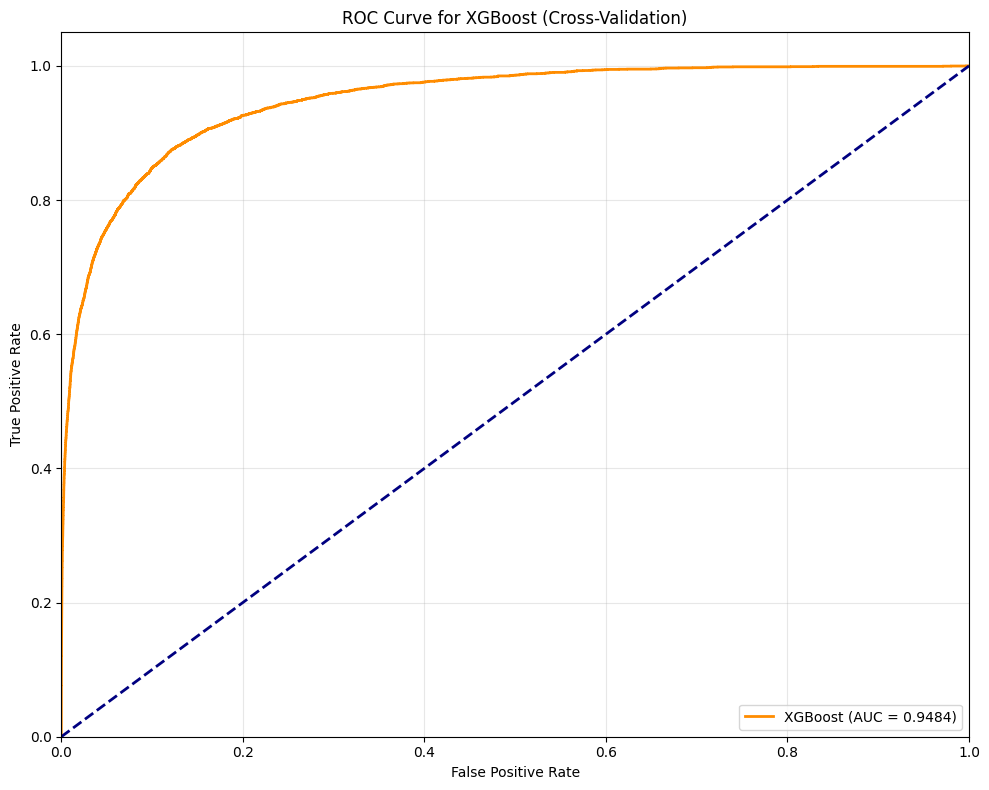

In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict  # Importar cross_val_predict
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Definir los rangos de hiperparámetros (con max_depth fijo en 9)
param_grid = {
    'learning_rate': np.arange(0.1, 0.31, 0.05),
    'reg_lambda': np.arange(3.5, 4.51, 0.1),
    'n_estimators': list(range(190, 201, 1))
}

# Definir el modelo de XGBoost con max_depth fijo en 9
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=9
)

# Definir la validación cruzada con StratifiedKFold (10 folds)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Configurar GridSearchCV con verbose=3 para ver el progreso en detalle
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='neg_log_loss',
    cv=cv,
    verbose=3,
    n_jobs=-1
)

# Ajustar GridSearchCV
grid_search.fit(X, y)

# Imprimir los mejores hiperparámetros encontrados
print("Mejores hiperparámetros:", grid_search.best_params_)

# Obtener el mejor modelo
best_model = grid_search.best_estimator_

# Realizar predicciones con el mejor modelo
y_pred_proba_cv = cross_val_predict(best_model, X, y, cv=cv, method='predict_proba')[:, 1]
y_pred_cv = cross_val_predict(best_model, X, y, cv=cv)

# Cálculo de las métricas usando validación cruzada
log_loss_cv = log_loss(y, y_pred_proba_cv)
print(f"Log Loss (CV): {log_loss_cv:.6f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y, y_pred_cv)
print("Matriz de confusión (CV):")
print(conf_matrix)

# Exactitud (accuracy)
accuracy = accuracy_score(y, y_pred_cv)
print(f"Accuracy (CV): {accuracy:.6f}")

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y, y_pred_proba_cv)
roc_auc = auc(fpr, tpr)
print(f"AUC (CV): {roc_auc:.6f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost (Cross-Validation)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

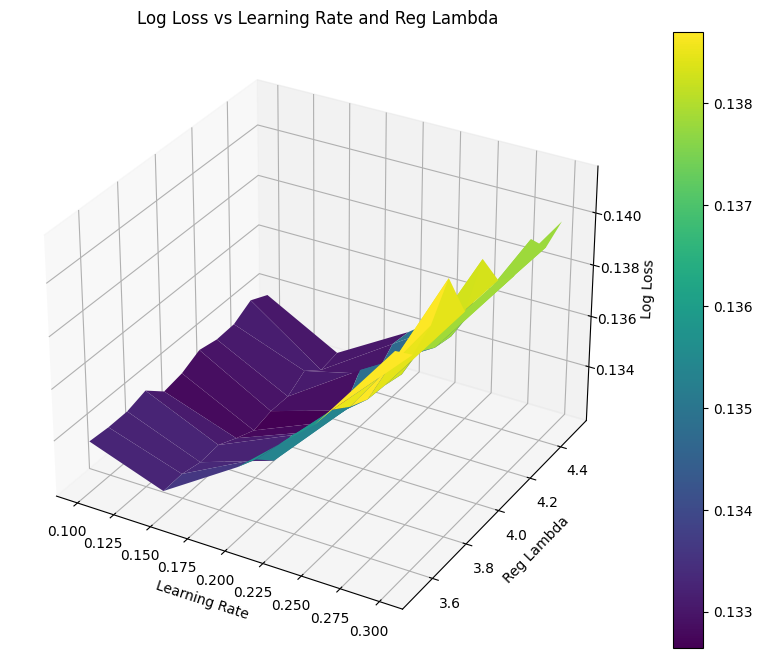

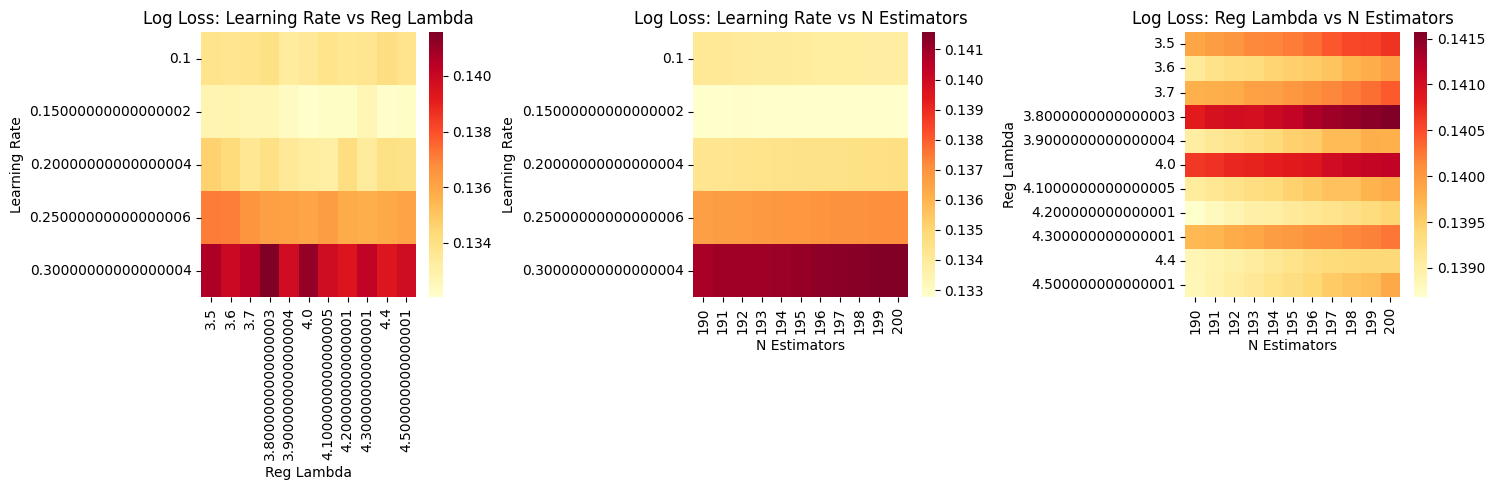

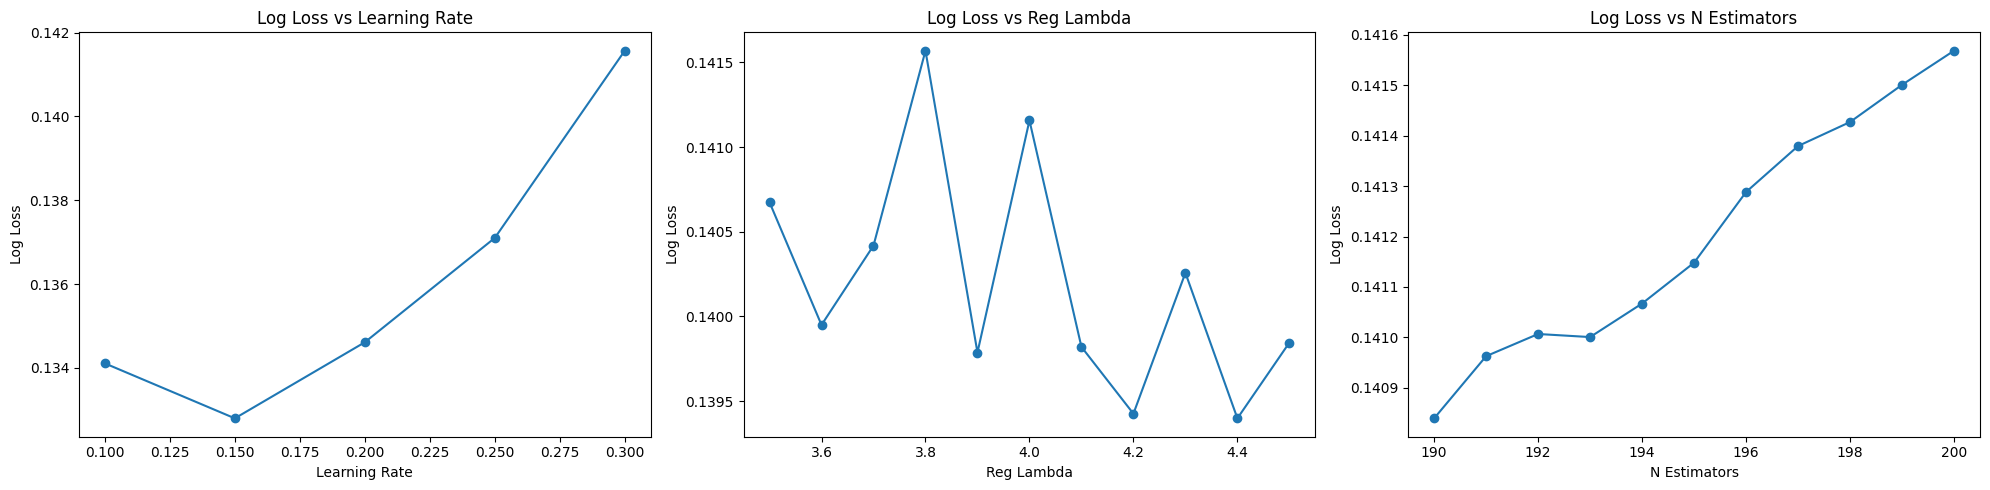

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Utiliza los resultados del GridSearchCV
results_df = pd.DataFrame(grid_search.cv_results_)

# Extraer los valores únicos de los hiperparámetros
learning_rates = sorted(results_df['param_learning_rate'].unique())
reg_lambdas = sorted(results_df['param_reg_lambda'].unique())
n_estimators = sorted(results_df['param_n_estimators'].unique())

# Convertir los resultados de neg_log_loss a log_loss (mean_test_score es negativo)
logloss_scores = -results_df['mean_test_score'].values

# 1. Gráfico de superficie 3D: Log Loss vs Learning Rate y Reg Lambda
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

X, Y = np.meshgrid(learning_rates, reg_lambdas)
Z = np.zeros_like(X)

for i, lr in enumerate(learning_rates):
    for j, reg in enumerate(reg_lambdas):
        Z[j, i] = -results_df[(results_df['param_learning_rate'] == lr) & (results_df['param_reg_lambda'] == reg)]['mean_test_score'].min()

surf = ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Reg Lambda')
ax.set_zlabel('Log Loss')
ax.set_title('Log Loss vs Learning Rate and Reg Lambda')
fig.colorbar(surf)
plt.show()

# 2. Heatmaps
plt.figure(figsize=(15, 5))

# Learning Rate vs Reg Lambda
plt.subplot(131)
heatmap_data = np.zeros((len(learning_rates), len(reg_lambdas)))
for i, lr in enumerate(learning_rates):
    for j, reg in enumerate(reg_lambdas):
        heatmap_data[i, j] = -results_df[(results_df['param_learning_rate'] == lr) & (results_df['param_reg_lambda'] == reg)]['mean_test_score'].min()
sns.heatmap(heatmap_data, xticklabels=reg_lambdas, yticklabels=learning_rates, cmap='YlOrRd')
plt.xlabel('Reg Lambda')
plt.ylabel('Learning Rate')
plt.title('Log Loss: Learning Rate vs Reg Lambda')

# Learning Rate vs N Estimators
plt.subplot(132)
heatmap_data = np.zeros((len(learning_rates), len(n_estimators)))
for i, lr in enumerate(learning_rates):
    for j, n in enumerate(n_estimators):
        heatmap_data[i, j] = -results_df[(results_df['param_learning_rate'] == lr) & (results_df['param_n_estimators'] == n)]['mean_test_score'].min()
sns.heatmap(heatmap_data, xticklabels=n_estimators[::1], yticklabels=learning_rates, cmap='YlOrRd')
plt.xlabel('N Estimators')
plt.ylabel('Learning Rate')
plt.title('Log Loss: Learning Rate vs N Estimators')

# Reg Lambda vs N Estimators
plt.subplot(133)
heatmap_data = np.zeros((len(reg_lambdas), len(n_estimators)))
for i, reg in enumerate(reg_lambdas):
    for j, n in enumerate(n_estimators):
        heatmap_data[i, j] = -results_df[(results_df['param_reg_lambda'] == reg) & (results_df['param_n_estimators'] == n)]['mean_test_score'].min()
sns.heatmap(heatmap_data, xticklabels=n_estimators[::1], yticklabels=reg_lambdas, cmap='YlOrRd')
plt.xlabel('N Estimators')
plt.ylabel('Reg Lambda')
plt.title('Log Loss: Reg Lambda vs N Estimators')

plt.tight_layout()
plt.show()

# 3. Gráficos de línea
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

# Learning Rate
lr_scores = [-results_df[results_df['param_learning_rate'] == lr]['mean_test_score'].min() for lr in learning_rates]
ax1.plot(learning_rates, lr_scores, marker='o')
ax1.set_xlabel('Learning Rate')
ax1.set_ylabel('Log Loss')
ax1.set_title('Log Loss vs Learning Rate')

# Reg Lambda
reg_scores = [-results_df[results_df['param_reg_lambda'] == reg]['mean_test_score'].min() for reg in reg_lambdas]
ax2.plot(reg_lambdas, reg_scores, marker='o')
ax2.set_xlabel('Reg Lambda')
ax2.set_ylabel('Log Loss')
ax2.set_title('Log Loss vs Reg Lambda')

# N Estimators
n_scores = [-results_df[results_df['param_n_estimators'] == n]['mean_test_score'].min() for n in n_estimators]
ax3.plot(n_estimators, n_scores, marker='o')
ax3.set_xlabel('N Estimators')
ax3.set_ylabel('Log Loss')
ax3.set_title('Log Loss vs N Estimators')

plt.tight_layout()
plt.show()

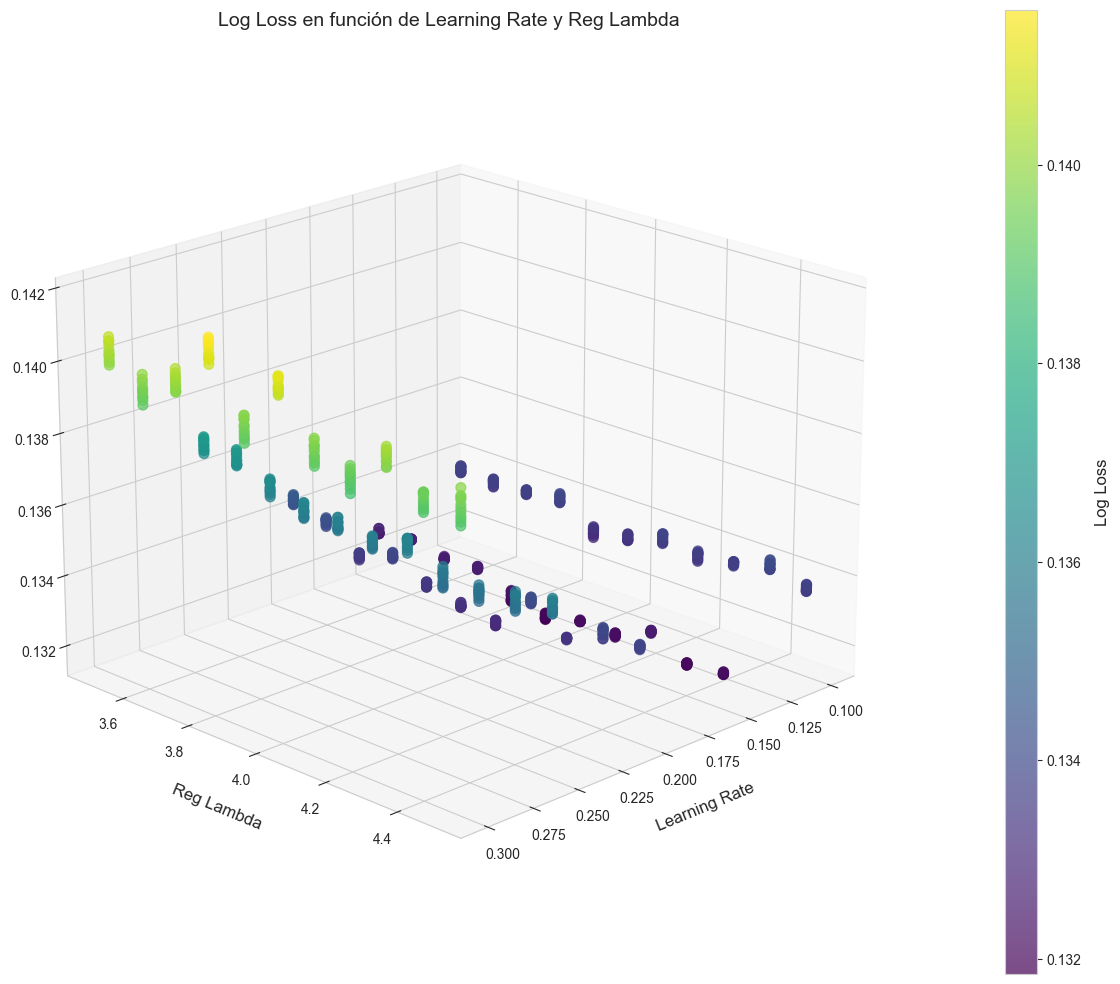

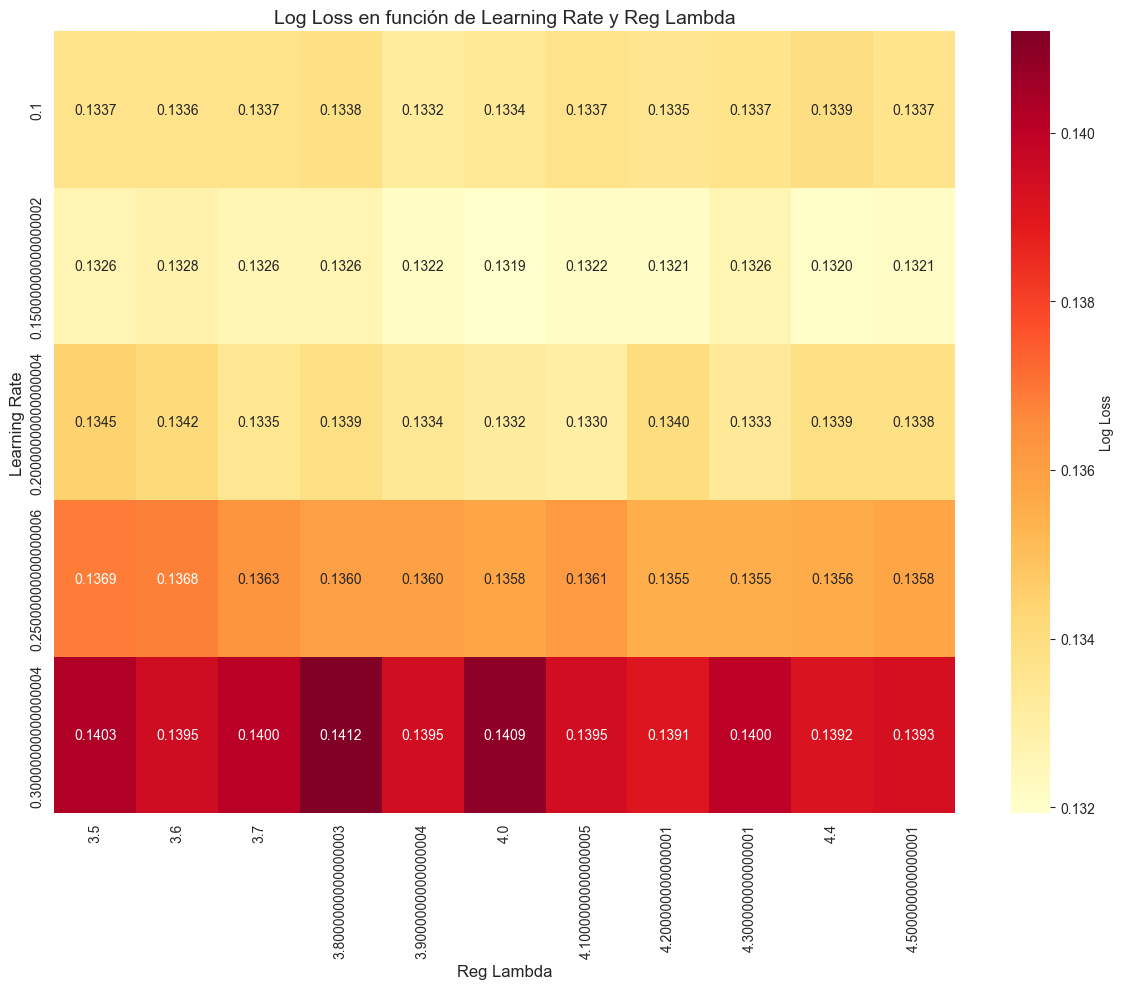

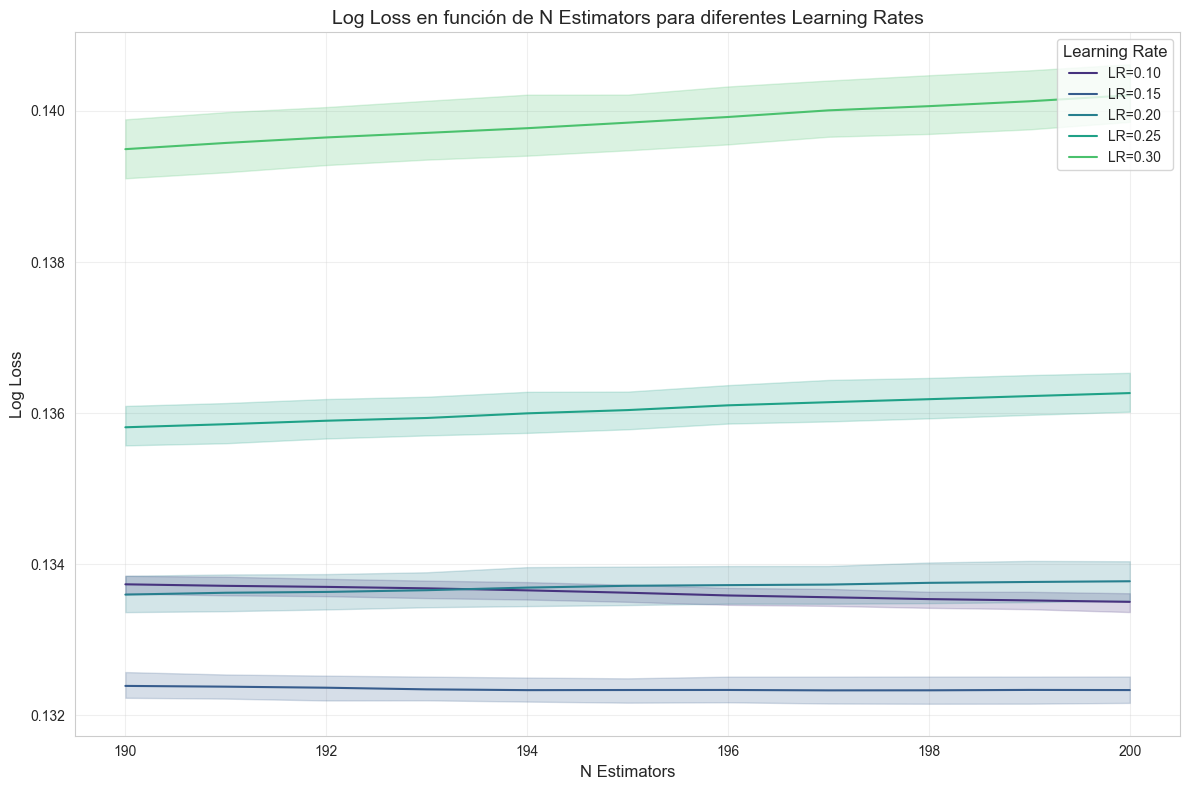

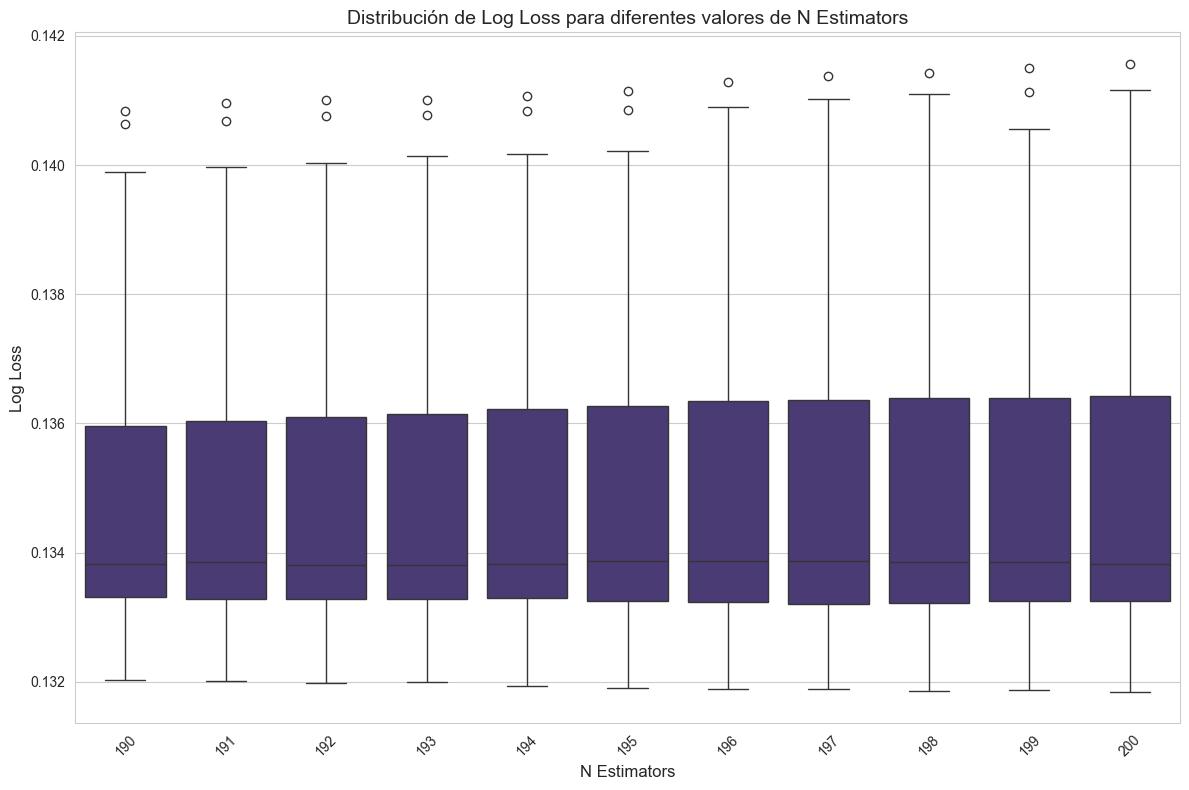

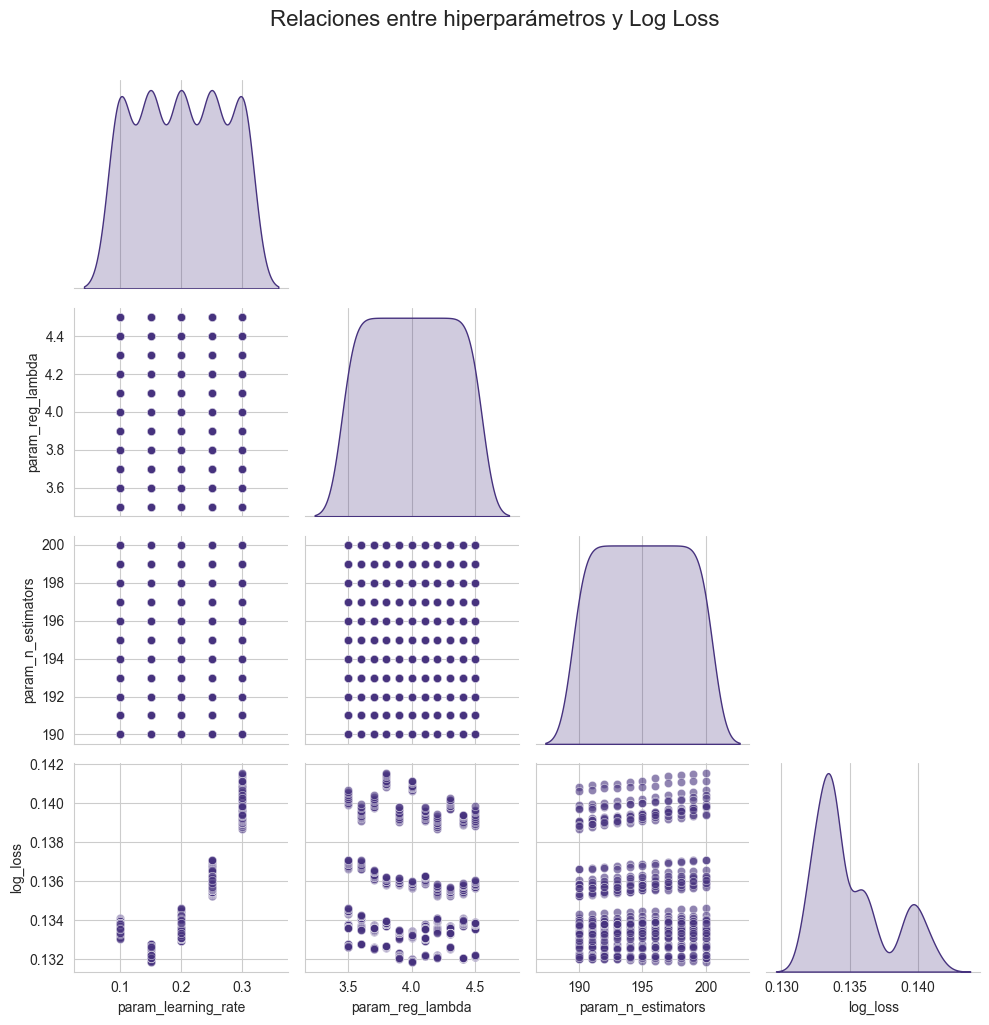


Mejores hiperparámetros encontrados:
Learning Rate: 0.1500
Reg Lambda: 4.0000
N Estimators: 200
Log Loss: 0.1318


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Aquí asumimos que 'results_df' ya contiene los resultados de RandomizedSearchCV:
# 'param_learning_rate', 'param_reg_lambda', 'param_n_estimators', 'mean_test_score'

# Convertir los resultados de neg_log_loss a log_loss (neg_test_score es negativo)
results_df['log_loss'] = -results_df['mean_test_score']

# Configuración del estilo de seaborn
sns.set_style("whitegrid")
sns.set_palette("viridis")

# Visualización 1: Gráfica 3D mejorada de learning_rate, reg_lambda y log_loss
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(results_df['param_learning_rate'], 
                     results_df['param_reg_lambda'], 
                     results_df['log_loss'], 
                     c=results_df['log_loss'], 
                     cmap='viridis', 
                     s=50, 
                     alpha=0.7)

ax.set_xlabel('Learning Rate', fontsize=12, labelpad=10)
ax.set_ylabel('Reg Lambda', fontsize=12, labelpad=10)
ax.set_zlabel('Log Loss', fontsize=12, labelpad=10)

cbar = fig.colorbar(scatter, ax=ax, pad=0.1, aspect=30)
cbar.set_label('Log Loss', fontsize=12, labelpad=10)

ax.set_title('Log Loss en función de Learning Rate y Reg Lambda', fontsize=14, pad=20)

# Rotar la vista para una mejor perspectiva
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

# Visualización 2: Heatmap de Log Loss en función de Learning Rate y Reg Lambda
plt.figure(figsize=(12, 10))
pivot_table = results_df.pivot_table(values='log_loss', 
                                     index='param_learning_rate', 
                                     columns='param_reg_lambda', 
                                     aggfunc='mean')

sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='YlOrRd', cbar_kws={'label': 'Log Loss'})
plt.title('Log Loss en función de Learning Rate y Reg Lambda', fontsize=14)
plt.xlabel('Reg Lambda', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.tight_layout()
plt.show()

# Visualización 3: Gráfica de líneas mejorada de n_estimators y log_loss
plt.figure(figsize=(12, 8))

for lr in sorted(results_df['param_learning_rate'].unique()):
    subset = results_df[results_df['param_learning_rate'] == lr]
    sns.lineplot(x='param_n_estimators', y='log_loss', data=subset, label=f'LR={lr:.2f}')

plt.xlabel('N Estimators', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.title('Log Loss en función de N Estimators para diferentes Learning Rates', fontsize=14)
plt.legend(title='Learning Rate', title_fontsize='12', fontsize='10')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualización 4: Box plot de Log Loss para diferentes valores de N Estimators
plt.figure(figsize=(12, 8))
sns.boxplot(x='param_n_estimators', y='log_loss', data=results_df)
plt.xlabel('N Estimators', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.title('Distribución de Log Loss para diferentes valores de N Estimators', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualización 5: Pair plot para todas las variables
sns.pairplot(results_df, vars=['param_learning_rate', 'param_reg_lambda', 'param_n_estimators', 'log_loss'], 
             corner=True, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Relaciones entre hiperparámetros y Log Loss', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Imprimir los mejores hiperparámetros
best_params = results_df.loc[results_df['log_loss'].idxmin()]
print("\nMejores hiperparámetros encontrados:")
print(f"Learning Rate: {best_params['param_learning_rate']:.4f}")
print(f"Reg Lambda: {best_params['param_reg_lambda']:.4f}")
print(f"N Estimators: {best_params['param_n_estimators']}")
print(f"Log Loss: {best_params['log_loss']:.4f}")

## Verificar con Cross Validation

Log Loss (CV): 0.131844
Matriz de confusión (CV):
[[48148   499]
 [ 2011  2323]]
Accuracy (CV): 0.952625
AUC (CV): 0.948433


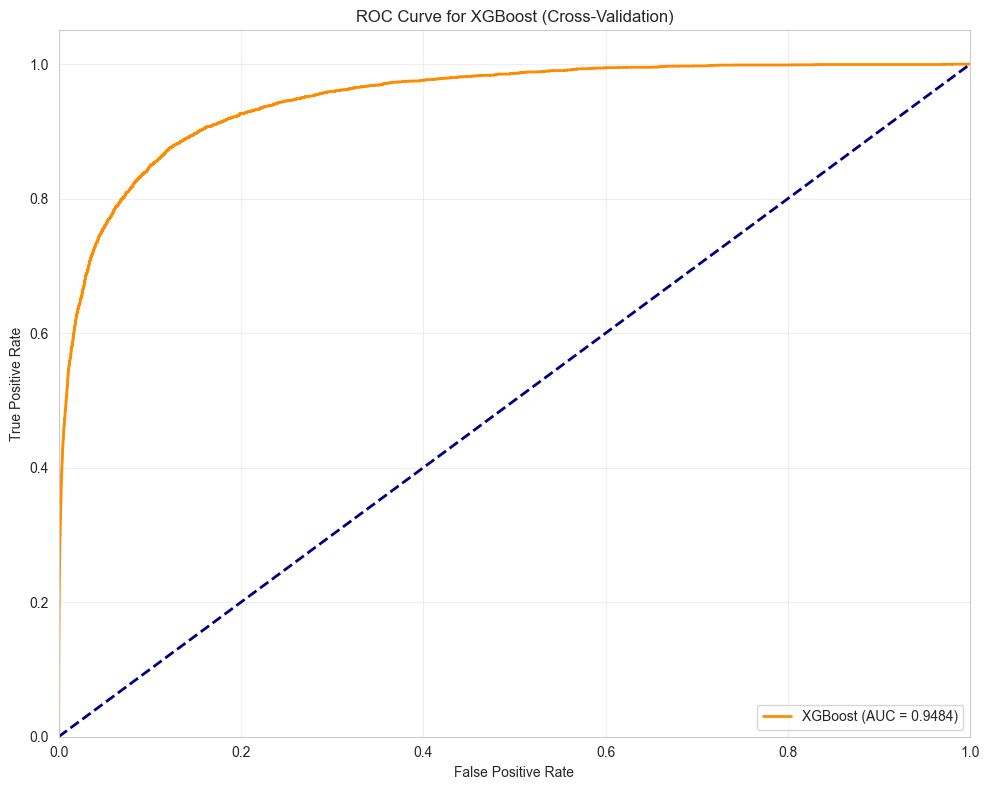

In [4]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Usar los mejores hiperparámetros obtenidos en el GridSearchCV
best_params = grid_search.best_params_

# Definir el modelo de XGBoost con los mejores hiperparámetros encontrados
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=9,  # Mantener el max_depth fijo en 9 como se especificó
    learning_rate=best_params['learning_rate'],
    reg_lambda=best_params['reg_lambda'],
    n_estimators=best_params['n_estimators']
)

# Definir la validación cruzada con StratifiedKFold (10 folds)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Ajustar el modelo con todos los datos antes de usar cross_val_predict
xgb_model.fit(X, y)

# Realizar predicciones con validación cruzada
y_pred_proba_cv = cross_val_predict(xgb_model, X, y, cv=cv, method='predict_proba')[:, 1]
y_pred_cv = cross_val_predict(xgb_model, X, y, cv=cv)

# Cálculo de las métricas usando validación cruzada
log_loss_cv = log_loss(y, y_pred_proba_cv)
print(f"Log Loss (CV): {log_loss_cv:.6f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y, y_pred_cv)
print("Matriz de confusión (CV):")
print(conf_matrix)

# Exactitud (accuracy)
accuracy = accuracy_score(y, y_pred_cv)
print(f"Accuracy (CV): {accuracy:.6f}")

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y, y_pred_proba_cv)
roc_auc = auc(fpr, tpr)
print(f"AUC (CV): {roc_auc:.6f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.4f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost (Cross-Validation)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Genera Archivo

In [5]:
import pandas as pd
from datetime import datetime

# Cargar el archivo de prueba
test_data = pd.read_csv('hoteles-prueba-limpio-normalizado.csv')

# Extraer la columna "id" y preparar los datos para predicción
test_ids = test_data['id']
X_test_data = test_data.drop(columns=['id'])

# Generar las probabilidades de predicción usando el modelo entrenado
y_pred_proba_test = xgb_model.predict_proba(X_test_data)[:, 1]

# Crear el archivo con timestamp
timestamp = datetime.now().strftime("%Y_%m_%d_%H_%M")
file_name = f'kaggle_submission_{timestamp}.csv'
kaggle_submission = pd.DataFrame({'id': test_ids, 'prob': y_pred_proba_test})

# Guardar el archivo para Kaggle
kaggle_submission.to_csv(file_name, index=False)

print(f"Archivo '{file_name}' creado con éxito para Kaggle.")

Archivo 'kaggle_submission_2024_10_20_20_45.csv' creado con éxito para Kaggle.
